In [8]:
#importing .gz files 
import gzip 
import numpy as np 

#graphite file (check)
filename = 'Gra_81.gz'
print(f"--- Reading headers/comments from {filename} ---")
with gzip.open(filename, 'rt') as f:
    for i in range(15): # Print the first 15 lines
        line = f.readline()
        print(line, end='')

#silicate file (check)
filename = 'Sil_81.gz'
print(f"--- Reading headers/comments from {filename} ---")
with gzip.open(filename, 'rt') as f:
    for i in range(15): # Print the first 15 lines
        line = f.readline()
        print(line, end='')

--- Reading headers/comments from Gra_81.gz ---
Wed Jun  2 11:05:12 EDT 1993
Graphite, 1/3-2/3 approximation, T=25K  
Computed by B.T.Draine (cf Laor, A., & Draine, B.T. 1993, ApJ 402,441)
  81 1.000E-03 1.000E+01 = NRAD, a_1 (micron), a_NRAD (micron)
 241 1.000E+03 1.000E-03 = NWAV, w_1 (micron), w_NWAV (micron)

1.000E-03 = radius(micron) Graphite, 1/3-2/3 approximation, T=25K  
w(micron)  Q_abs     Q_sca     g=<cos>
1.000E+03 2.403E-07 4.131E-21  0.00E+00
9.441E+02 2.674E-07 5.200E-21  0.00E+00
8.913E+02 2.978E-07 6.546E-21  0.00E+00
8.414E+02 3.319E-07 8.240E-21  0.00E+00
7.943E+02 3.701E-07 1.037E-20  0.00E+00
7.499E+02 4.128E-07 1.306E-20  0.00E+00
7.079E+02 4.608E-07 1.644E-20  0.00E+00
--- Reading headers/comments from Sil_81.gz ---
Wed Jun  2 11:05:12 EDT 1993
Astronomical silicate                   
Computed by B.T.Draine (cf Laor, A., & Draine, B.T. 1993, ApJ 402,441)
  81 1.000E-03 1.000E+01 = NRAD, a_1 (micron), a_NRAD (micron)
 241 1.000E+03 1.000E-03 = NWAV, w_1 (micron)

In [9]:
import numpy as np 
import matplotlib.pyplot as plt

In [10]:
#constants

#bulk densities [g cm^-3] (from Bruce Draine)
rho_gra = 2.24
rho_sil = 3.5 

#physical constants
h = 6.62607015e-24 #Planck [J s]
c = 2.99792458e8 #speed of light [m s^-1]
k_B = 1.380649e-23 #boltzmann [J k^-1]

In [11]:
#func computing BB flux, returns B_lambda in cgs 
def planck_wavelength(micron, T):
    
    #convert microns to cm 1micron=1e-4cm
    cm = micron * 1e-4
    
    #CGS constants 
    h_cgs = 6.62607015e-27 #Planck [erg s]
    c_cgs = 2.99792458e10 #speed of light [cm s^-1]
    k_cgs = 1.380649e-16 #boltzmann [erg k^-1]
    
    exponent = (h_cgs *c_cgs) / (cm * k_cgs * T)
    
    #limit huge results over 500
    exponent = np.clip(exponent, 1e-10, 500)
    
    #planck func for B_lambda in CGS
    b_lam = (2 *h_cgs * c_cgs**2) / (cm**5 * (np.exp(exponent) -1))
    
    return b_lam 

In [19]:
def parse_bruce_data(filepath):



    with gzip.open(filepath, 'rt') as f: #reads and opens file

        lines = f.readlines() #reads every line and stores 

    radii_list = [] #empty list to store grain radius size for each data block

    wavelengths = None #placeholder, will be wavelength grid array from blocks

    Q_abs_matrix = [] #creates list holding absoprtion efficiency values Qabs

    Q_sca_matrix = [] #create list to hold scat efficiency values Qsca


    i=0 #index at 1st line of file

    while i< len(lines): #while loop, read every line through file

        line = lines[i].strip() #grabs line and cleans away useless characters


        #checking if new radius block

        if 'radius(micron)' in line: #scanning for "radius(micron)"

            parts = line.split() #extracting radius value from start of line

            current_radius = float(parts[0]) #grabbing first piece of list, converting to number(grain size)

            radii_list.append(current_radius) #adds grain radius to list


            #skip past the column headers
            i +=4


            block_waves= [] #create empty list for specific grain size

            blocks_qabs = [] #Q abs absorption coefficiency to calc mass absorp coeff kappanu, for specific grain size

            blocks_qsca = [] # Q sca scattering efficiency, for THIS grain block


            #read rows until hit end of text

            while i< len(lines): #sub-loop to read rows inside current block

                cols = lines[i].split() #split data into list of cols

                #if line doesn't have at least 4 numerical col, already hit next block
                if len(cols)<4:

                    break

                try: #sub-loop safety to convert col to floats (number), can probs ignore this was a suggested add by ai 

                    w = float(cols[0])

                    qabs = float(cols[1])

                    qsca = float(cols[2])


                    block_waves.append(w)

                    blocks_qabs.append(qabs)

                    blocks_qsca.append(qsca)

                except ValueError:

                    break

                i +=1



#save waveelength grid once for every radius block, storing and returning

            if wavelengths is None: #every grain size block uses same wavelength grid, get the array once and move on

                wavelengths = np.array(block_waves)


            Q_abs_matrix.append(blocks_qabs) #append completed list of Qabs for this grain size into matrix

            Q_sca_matrix.append(blocks_qsca) #same as above, but for Qsca


        else:

            i +=1 #if a line isnt a radius block, increments by a step and moves on 

    return wavelengths, np.array(radii_list), np.array(Q_abs_matrix), np.array(Q_sca_matrix) #once scan file, extract numpy arrays for 4 outputs


wavelengths_sil, radii_sil, Q_abs_sil, Q_sca_sil = parse_bruce_data('Sil_81.gz')

print(f"Radii count: {len(radii)}, Wavelengths count: {len(wavelengths)}")

wavelengths_gra, radii_gra, Q_abs_gra, Q_sca_gra = parse_bruce_data('Gra_81.gz')

print(f"Radii count: {len(radii)}, Wavelengths count: {len(wavelengths)}")

Radii count: 81, Wavelengths count: 239
Radii count: 81, Wavelengths count: 239


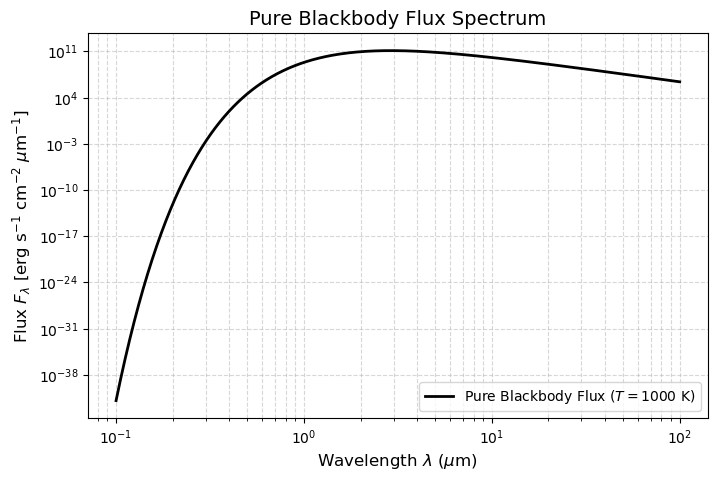

In [18]:
#setting up BB spectrum without dust

micron = np.logspace (-1, 2, 500) #wavelength grid from 0.1 to 10 micron

temperature = 1000 #choosing 1000 K

intensity = planck_wavelength(micron, temperature)

flux_surface = np.pi *intensity #converting intensity to flux unit

#plot
plt.figure(figsize=(8, 5))
plt.plot(micron, flux_surface, color='black', lw=2, label=f'Pure Blackbody Flux ($T = {temperature}$ K)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Wavelength $\lambda$ ($\mu$m)', fontsize=12)
plt.ylabel(r'Flux $F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\mu$m$^{-1}$]', fontsize=12)
plt.title('Pure Blackbody Flux Spectrum', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

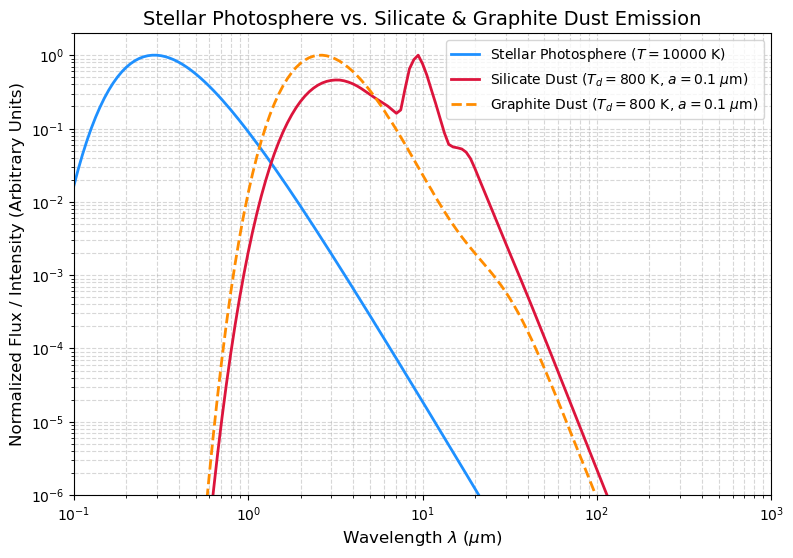

In [ ]:
#Replicate Figure 4 for silicate and graphite 

T_dust= 800 #warm dust in K
stellar_temp = 10000
target_radius= 0.1 #chosen grain size 

#silicate calculations 
r_idx_sil= np.argmin(np.abs(radii_sil - target_radius)) #find index # where grain size in file closest to my target 0.1micron
a_cm_sil = radii_sil[r_idx_sil] * 1e-4 #grabs radius match and converts micron to cm 
q_abs_sil_single = Q_abs_sil[r_idx_sil, :] #grabs entire row of grain size, giving array of Qabs values from all wavelengths 
kappa_sil = (3 * q_abs_sil_single) / (4 * rho_sil * a_cm_sil) #compute mass absorption coeff, result is cm^2 g^-1

#graphite calc
r_idx_gra= np.argmin(np.abs(radii_gra - target_radius))
a_cm_gra = radii_gra[r_idx_gra] * 1e-4
q_abs_gra_single = Q_abs_gra[r_idx_gra, :]
kappa_gra = (3 * q_abs_gra_single) / (4 * rho_gra * a_cm_gra)

#spectra calc using planck func
b_lambda_dust = planck_wavelength(wavelengths_sil, T_dust) #compute BB intensity across wavelength at warm temperature 
stellar_bb = planck_wavelength(wavelengths_sil, stellar_temp) #compute BB spectrum for hot photosphere

#mod dust spectra opacity*planck
mod_dust_sil = kappa_sil * b_lambda_dust #mult material wavelength-dep opacity (kappa) by thermal BB emission (B), yields optically thin dust emission spectrum, shows how dust reddens, far-infrared
mod_dust_gra  = kappa_gra * b_lambda_dust 

#normalize and fit for shape on logarithmic plot, can drop 
stellar_norm = stellar_bb / np.max(stellar_bb) #divides each spectrum by own peak value, visualizing how stellar peak sits in opt/UV with dust peak infrared
dust_sil_norm = mod_dust_sil / np.max(mod_dust_sil)
dust_gra_norm = mod_dust_gra / np.max(mod_dust_gra)

#ai plot for visual pleasure 
# --- PLOTTING COMPARISON ---
plt.figure(figsize=(9, 6))

plt.plot(wavelengths_sil, stellar_norm, color='dodgerblue', lw=2, 
         label=f'Stellar Photosphere ($T = {stellar_temp}$ K)')
plt.plot(wavelengths_sil, dust_sil_norm, color='crimson', lw=2, linestyle='-', 
         label=f'Silicate Dust ($T_d = {T_dust}$ K, $a = {radii_sil[r_idx_sil]}$ $\mu$m)')
plt.plot(wavelengths_sil, dust_gra_norm, color='darkorange', lw=2, linestyle='--', 
         label=f'Graphite Dust ($T_d = {T_dust}$ K, $a = {radii_gra[r_idx_gra]}$ $\mu$m)')

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1, 1000.0)
plt.ylim(1e-6, 2.0)

plt.xlabel(r'Wavelength $\lambda$ ($\mu$m)', fontsize=12)
plt.ylabel(r'Normalized Flux / Intensity (Arbitrary Units)', fontsize=12)
plt.title('Stellar Photosphere vs. Silicate & Graphite Dust Emission', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In [ ]:
#loop to plot all radii up to 10 micron 

plt.figure(figsize=(9,6))

for idx, 